# Primer punto

El dataset suministrado contiene alrededor de 32 columnas y 58895 filas. Contiene información relacionada al servicio de hospedaje ofrecido 
por un conjunto de hoteles. Asimismo, contiene informacion del estado y fecha de la reserva, incluyendo datos del cliente, el tipo 
de plan escogido por el usuario, la compañia encargada del pago o de realizar la reserva, cancelaciones, entre otros.
Los tipos de datos encontrados en el dataset son: text, boolean, integer, numeric y date.
A continuación se presenta el top 5 atributos elegidos:
* hotel                   (Cualitativa nominal):,
* reservation_status      (Cualitativa nominal),
* deposit_type            (Cualitativa nominal),
* is_Canceled             (Cualitativa nominal),
* lead_time               (cuantitativa discreta)

### Carga y limpieza de Datos

In [ ]:
# Importación de librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# transformación columnas a tipo entero
def convertir_string(cast_columns_int,df):
    for i in cast_columns_int:
        df[i]=(
        pd.to_numeric(df[i], errors="coerce")
          .round()
          .astype("Int64")
        )
# transformación columnas a tipo fecha
def convertir_date(cast_columns_date,df):
    for i in cast_columns_date:
        df[i]=(
        pd.to_datetime(df[i], errors="coerce")
        )

# limpieza columnas tipo string (object) 
def eliminar_espacios(columns_object,df):
    df[columns_object]=df[columns_object].apply(lambda x: x.str.strip())

In [2]:
# carga fuente insumo
reservation_df = pd.read_csv("data/hotel_bookings_modified.csv")

C:\Users\Diego\AppData\Local\Temp\ipykernel_15440\3497737948.py:2: DtypeWarning: Columns (24) have mixed types. Specify dtype option on import or set low_memory=False.
  reservation_df = pd.read_csv("data/hotel_bookings_modified.csv")


In [3]:
# Dimensiones dataset
reservation_df.shape

(58895, 33)

In [22]:
# Lista de columnas a castear según lo indica el Diccionario de Datos
cast_columns_int = ["arrival_date_year","children","days_in_waiting_list","required_car_parking_spaces","total_of_special_requests","agent","company"]
cast_columns_date = ["reservation_status_date"]

#creacion de un nuevo dataframe que será transformado y limipiado
reservation_df_clean=reservation_df
# Casteo columnas a string segun el diccionario de datos 
convertir_string(cast_columns_int,reservation_df_clean)
# Casteo columnas a date segun el diccionario de datos 
convertir_date(cast_columns_date,reservation_df_clean)
#obtiene lista de columnas tipo "object"
columns_object = reservation_df_clean.select_dtypes(include="object").columns
# limpieza columnas string
eliminar_espacios(columns_object,reservation_df_clean)
#se eliminan duplicados
reservation_df_clean = reservation_df_clean.drop_duplicates()

### Analisis Univariado

#### Variable "hotel"

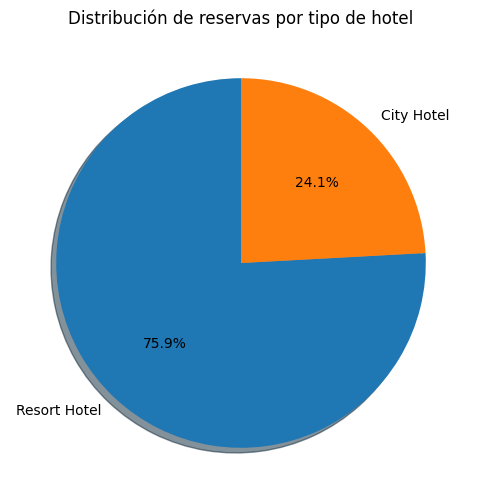

In [ ]:
# obtencion de valores unicos, el valor mas repetido y su frecuencia
reservation_df_clean["hotel"].describe()

# Calculando la tabla de frecuencias relativas
reservation_df_clean["hotel"].value_counts(dropna=False, normalize=True)

# Graficando frecuencias relativas variable hotel
reservation_df_clean["hotel"].value_counts().plot.pie(
    autopct='%1.1f%%',   # Muestra porcentajes
    figsize=(6, 6),      # Tamaño del gráfico
    startangle=90,       # Rotación inicial
    shadow=True          # Sombra opcional
)

plt.ylabel("")  # Quita la etiqueta del eje Y
plt.title("Distribución de reservas por tipo de hotel")
plt.show()

Cerca del 76% de las registros corresponden a "Resort Hotel" y el 24 % a "City hotel". Se puede deber a mayor demanda real en el "Resort Hotel" o a la existencia de mas datos en el tiempo respecto a "City Hotel". Más adelante se puede analizar las cancelaciones y reservas en el tiempo para entender mejor la causa.

#### Variable reservation_status

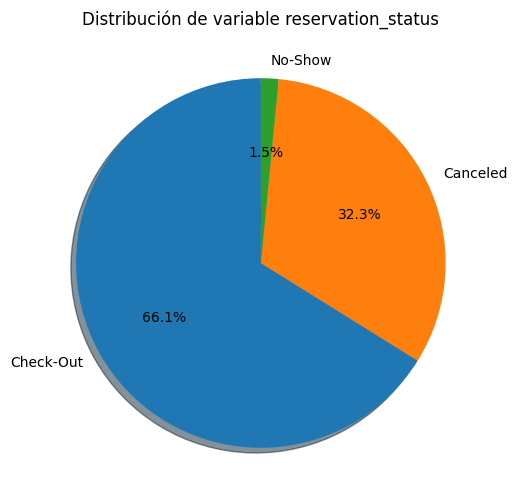

In [ ]:
# obtencion de valores unicos, conteo, moda
reservation_df_clean["reservation_status"].describe()
# Calculando la tabla de frecuencias del campo reservation_status
reservation_df_clean["reservation_status"].value_counts(dropna=False, normalize=True)

# Graficando frecuencias relativas variable reservation_status
reservation_df_clean["reservation_status"].value_counts().plot.pie(
    autopct='%1.1f%%',   # Muestra porcentajes
    figsize=(6, 6),      # Tamaño del gráfico
    startangle=90,       # Rotación inicial
    shadow=True          # Sombra opcional
)

plt.ylabel("")  # Quita la etiqueta del eje Y
plt.title("Distribución de variable reservation_status")
plt.show()

Cerca del 66% de las reservas son tomadas exitosamente. Hay un 32.3% de reservas que son canceladas, por lo que es importante analizar que factores conducieron a la cancelación por parte del cliente y que oportunidades de mejora se pueden aplicar en la estrategia de alojamiento del cliente. Finalmente, cerca del 1.5% de alojamientos no se hizo el check-in y el cliente informo el motivo. Si se tuviera la información relacionada al motivo, se podría analizar si esos motivos relacionan al servicio de hospedaje, pero como no se tiene, se plantea como un futuro análisis.

#### Variable deposit_type

C:\Users\Diego\AppData\Local\Temp\ipykernel_15440\3731212666.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reservation_df_clean["deposit_type"].replace("No Refund","Non Refund",inplace=True)
C:\Users\Diego\AppData\Local\Temp\ipykernel_15440\3731212666.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reservation_df_clean["deposit_type"

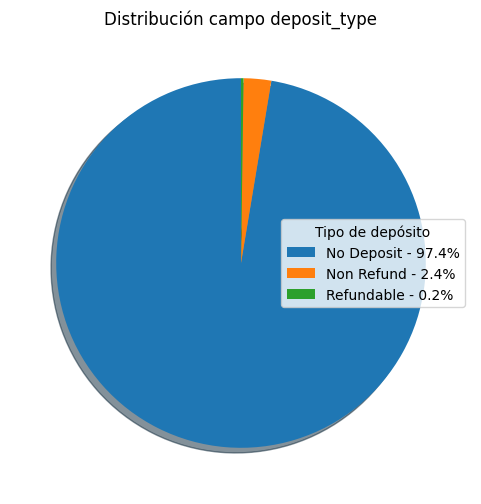

In [32]:
# Calculating the relative frecuency of accommodations offered
reservation_df_clean["deposit_type"].replace("No Refund","Non Refund",inplace=True)
# Conteo de valores
counts=reservation_df_clean["deposit_type"].value_counts()
percentages=reservation_df_clean["deposit_type"].value_counts(dropna=False, normalize=True)*100
# Crear etiquetas combinando categoría + porcentaje
labels = [f"{cat} - {perc:.1f}%" for cat, perc in zip(counts.index, percentages)]

# Crear el pie chart sin etiquetas
plt.figure(figsize=(6, 6))
plt.pie(counts, startangle=90, shadow=True)
# Agregar leyenda
plt.legend(labels, title="Tipo de depósito", loc="best")
plt.ylabel("")  # Quita etiqueta del eje Y
plt.title("Distribución campo deposit_type")
plt.show()


Cerca del 88% de los clientes no hacen un depositivo para realizar una reserva. El 10% de los clientes hacen el depositivo del 100%, pero no se devuelve si cancela. Y muy pocos clientes hacen un depositivo por un valor por debajo del costo de la reserva.

#### Variable is_canceled

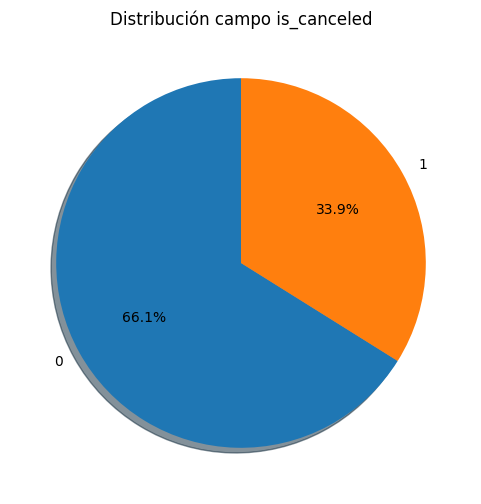

In [48]:
# obtain unique values, count, most repeat value
reservation_df_clean["is_canceled"].describe()
# Calculo frecuencias relativas 
reservation_df_clean["is_canceled"].value_counts(dropna=False, normalize=True)
# Graficando distribucion campo is_canceled
reservation_df_clean["is_canceled"].value_counts().plot.pie(
    autopct='%1.1f%%',   # Muestra porcentajes
    figsize=(6, 6),      # Tamaño del gráfico
    startangle=90,       # Rotación inicial
    shadow=True          # Sombra opcional
)
plt.ylabel("")  # Quita la etiqueta del eje Y
plt.title("Distribución campo is_canceled")
plt.show()

El 66.1% de los registros corresponden a reservas exitosas, y el 33.9% de reservas canceladas. 
El procentaje de cancelaciones es alto, significando una tercera parte del total de reservas
por lo que mas adelante se analizará que factores lleva a que exista tantas cancelaciones

#### Variable lead_time

In [50]:
# obteniendo prinicpales metricas como la mediana, los percentiles, completitud del campo
reservation_df["lead_time"].describe()

# Calculando el rango intercuartilico
# q1=reservation_df["lead_time"].quantile(0.25)
# q3=reservation_df["lead_time"].quantile(0.75)
# iqr=q3-q1

count    58895.000000
mean       100.050904
std        101.162420
min          0.000000
25%         17.000000
50%         69.000000
75%        157.000000
max        737.000000
Name: lead_time, dtype: float64


Mean = 100 → en promedio los alojamientos se reservan (incluye las reservas exitosas y canceladas) con 100 dias 
de anticipación (mas de 3 meses de anticipación)
- Q1 (25%) = 17          → El 25% de los alojamientos se reservan con 17 dias de antelación o menos
- Q2 (50%, mediana) = 69 → El 50% de los alojamientos se reservan con 69 dias de antelación o menos
- Q3 (75%) = 157         → El 75% de los alojamientos se reservan con 157 dias de antelación o menos

Rango intercuartílico (IQR):
- IQR= Q3 - Q1 = 140
- Límite inferior = Q1 - 1.5 × IQR = 17- 1.5*140  = 0    
- Límite superior = Q3 + 1.5 × IQR = 157+1.5*140  = 367

Entonces, alojamientos que son reservados con una antelacion ≥ 367 dias, se consideran valores atipicos

[]

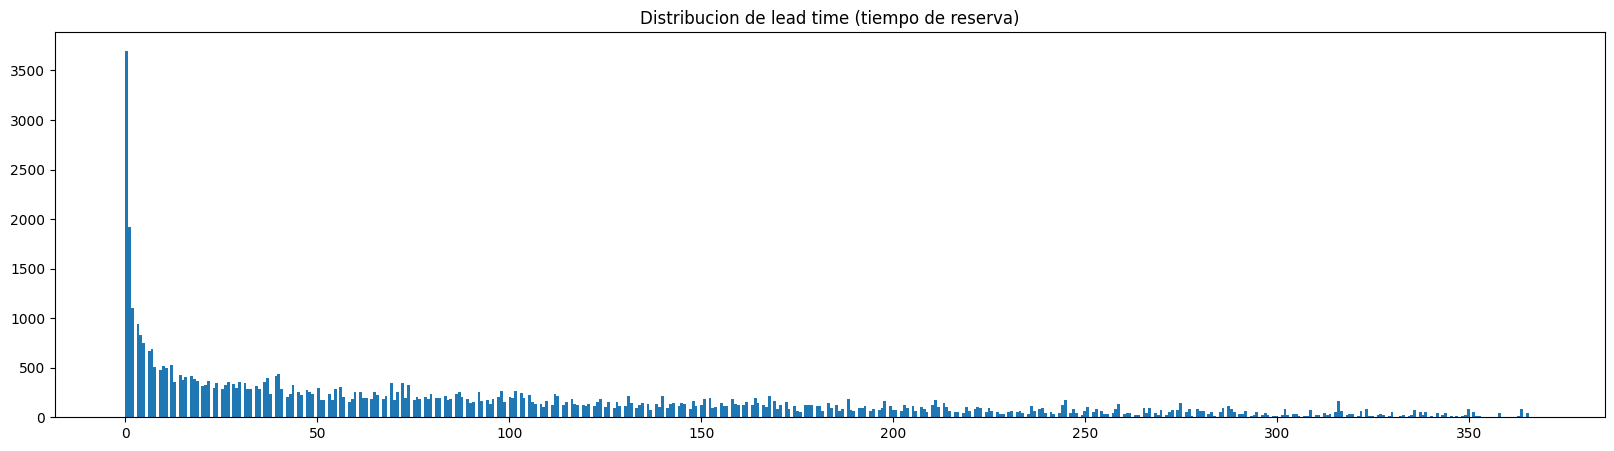

In [53]:
# graficando histograma para analizar la distribucion de la variable lead_time
plt.figure(figsize=(20, 5))
plt.hist(reservation_df.loc[reservation_df["lead_time"] <= (q3 + 1.5 * iqr)]["lead_time"], bins=500)
plt.title("Distribucion de lead time (tiempo de reserva)")
plt.plot()

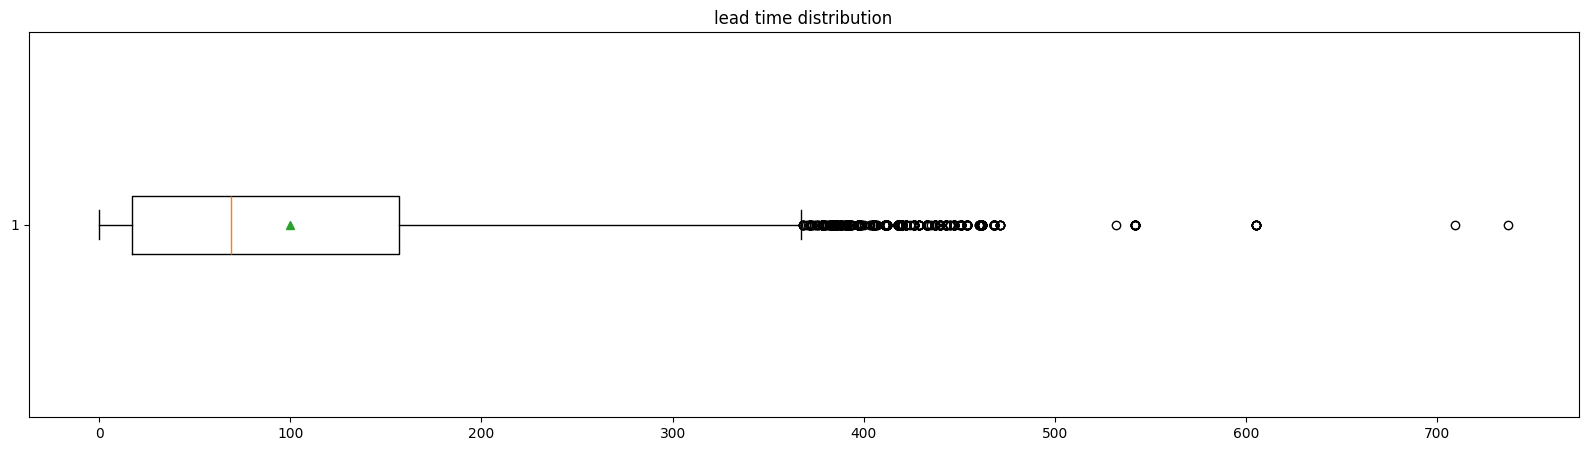

In [54]:

# Plotting a boxplot for number of reviews
plt.figure(figsize=(20, 5))
plt.boxplot(reservation_df["lead_time"], showmeans=True, vert=False)
plt.title("lead time distribution")
plt.show()

La media (triangulo verde) que es 100 esta no tan cerca de la mediana que es 69 dias (linea naranja ), por lo que existe una ligera asimetría positiva en la distribución, causada por la presencia de valores atípicos positivos grandes que están empujando la media hacia la derecha . Asimismo, los valores atipicos empiezan por encima de los 367 dias y se extienden hasta valores muy grandes ( 700 dias). La mayoria de los dias de antelacion de reserva (rango intercuartilico  Q3 - Q1), están entre 17 y 160 dias, lo que representa el comportamiento típico de los clientes.

In [55]:
# Asimetría
skewness = reservation_df["lead_time"].skew()
# Curtosis
kurtosis = reservation_df["lead_time"].kurt()
print("Asimetría (skewness):", skewness)
print("Curtosis:", kurtosis)

Asimetría (skewness): 1.2082573004591315
Curtosis: 1.0087856167757177


Como la asimetria arroja un valor positivo mayor a 1, nos confirma que distribución esta sesgada hacia la derecha. Entonces, existen unos valores positivos muy grandes que estan arrastrando la media hacia la derecha.
También, como la curtosis es cercano a uno la variable está sesgada a la derecha y presenta una concentración central fuerte con algunos valores atípicos altos que le dan colas más pesadas.